## Full plot generation pass
Add you plot implementations here when they are complete so that as we update and finish the second pass new sets of plots can be immediatly generated. Comment appropriatly and describe what the plot is showing.

PGF export TeX engine detected: none (PGF files will be skipped)
Dataset sizes (artifact present only):
    dataset  papers
 first_pass     211
second_pass     216
 optimistic     228
All-paper sizes -> first: 246, second: 240, optimistic: 246
Using plot dataframe: optimistic (228 papers)
Saved PNG plot to graphs\overall_fair_compliance_by_letter.png


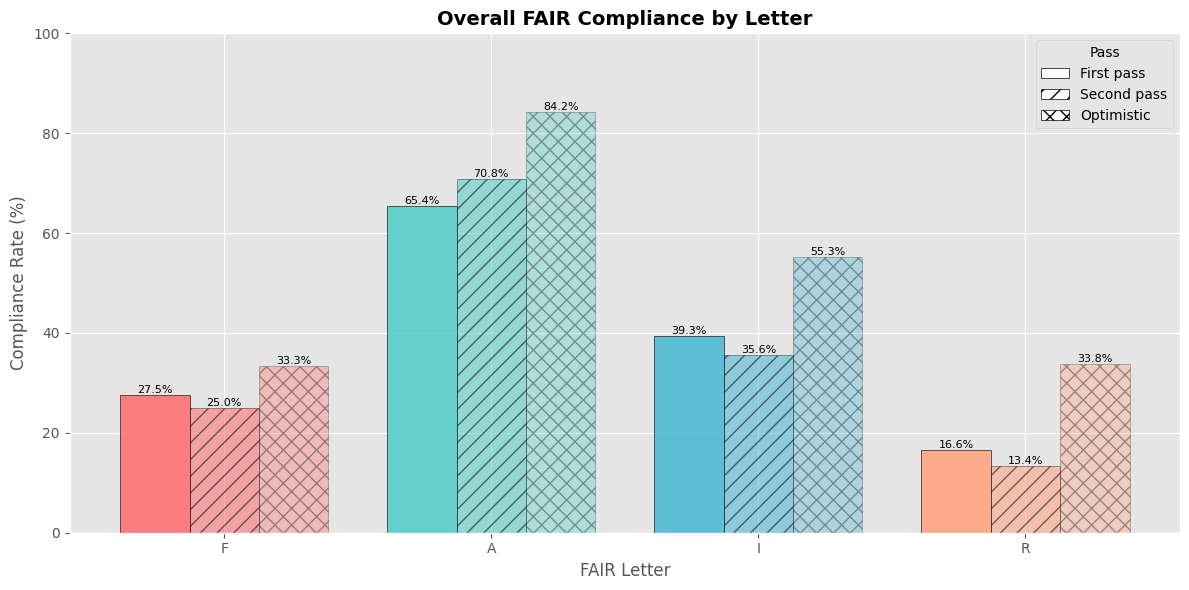

In [9]:
import importlib
import shutil
import pandas as pd
from plotting_scripts.FAIR_compliance import (
    F,
    A,
    I,
    R,
)
from plotting_scripts.repository_stats import repo_stats_main
import plotting_scripts.fair_letter_compliance as fair_letter_compliance
import processing_scripts.optimistic_dataset as optimistic_dataset

importlib.reload(fair_letter_compliance)
importlib.reload(optimistic_dataset)

# One-time PGF/TeX availability check for this run.
tex_candidates = ("pdflatex", "lualatex", "xelatex")
selected_tex_engine = next((tex for tex in tex_candidates if shutil.which(tex)), None)
if selected_tex_engine:
    print(f"PGF export TeX engine detected: {selected_tex_engine}")
else:
    print("PGF export TeX engine detected: none (PGF files will be skipped)")

# Load first/second pass datasets (all papers, then filtered views for standard FAIR plots)
sample_file = "results/FAIR Evaluation Results - First Pass Responses_fixed.csv"
second_sample_file = "results/FAIR Evaluation Results - Second Pass Responses_fixed.csv"

df_first_all = optimistic_dataset.load_pass_dataset(
    sample_file,
    drop_cols=optimistic_dataset.DEFAULT_DROP_COLUMNS,
    artifact_col=optimistic_dataset.ARTIFACT_COLUMN,
    artifacts_only=False,
)
df_second_all = optimistic_dataset.load_pass_dataset(
    second_sample_file,
    drop_cols=optimistic_dataset.DEFAULT_DROP_COLUMNS,
    artifact_col=optimistic_dataset.ARTIFACT_COLUMN,
    artifacts_only=False,
)

df = df_first_all[
    df_first_all[optimistic_dataset.ARTIFACT_COLUMN].astype(str).str.strip().str.lower() == "yes"
]
df_second = df_second_all[
    df_second_all[optimistic_dataset.ARTIFACT_COLUMN].astype(str).str.strip().str.lower() == "yes"
]

# Build optimistic dataset with OR logic across FAIR criteria and merged locations.
all_fair_criteria = F + A + I + R
df_optimistic_all = optimistic_dataset.build_optimistic_dataset(
    first_pass_df=df_first_all,
    second_pass_df=df_second_all,
    fair_criteria=all_fair_criteria,
    artifact_col=optimistic_dataset.ARTIFACT_COLUMN,
    artifacts_only=False,
)
df_optimistic = df_optimistic_all[
    df_optimistic_all[optimistic_dataset.ARTIFACT_COLUMN].astype(str).str.strip().str.lower() == "yes"
]

# Select dataframe to use in single-dataset plots.
plot_dataframes = {
    "first_pass": df,
    "second_pass": df_second,
    "optimistic": df_optimistic,
}

dataset_sizes = optimistic_dataset.get_dataset_size_table(df, df_second, df_optimistic)
print("Dataset sizes (artifact present only):")
print(dataset_sizes.to_string(index=False))
print(f"All-paper sizes -> first: {len(df_first_all)}, second: {len(df_second_all)}, optimistic: {len(df_optimistic_all)}")

selected_dataframe_name = "optimistic"  # choose: first_pass, second_pass, optimistic
plot_df = plot_dataframes[selected_dataframe_name]
print(f"Using plot dataframe: {selected_dataframe_name} ({len(plot_df)} papers)")

# Plot full FAIR compliance by letter for both real passes and optimistic
fair_letter_compliance.plot_fair_letter_compliance(df, df_second, df_optimistic)

In [ ]:
from plotting_scripts.fair_criterion_compliance import plot_fair_criterion_compliance

# Individual Letter Compliance Analysis (choose with selected_dataframe_name in Cell 2)
plot_fair_criterion_compliance(plot_df, F, A, I, R)

Saved PNG plot to graphs\fair_criterion_compliance_by_letter.png


Saved PNG plot to graphs\full_fair_outcome_breakdown_across_datasets.png


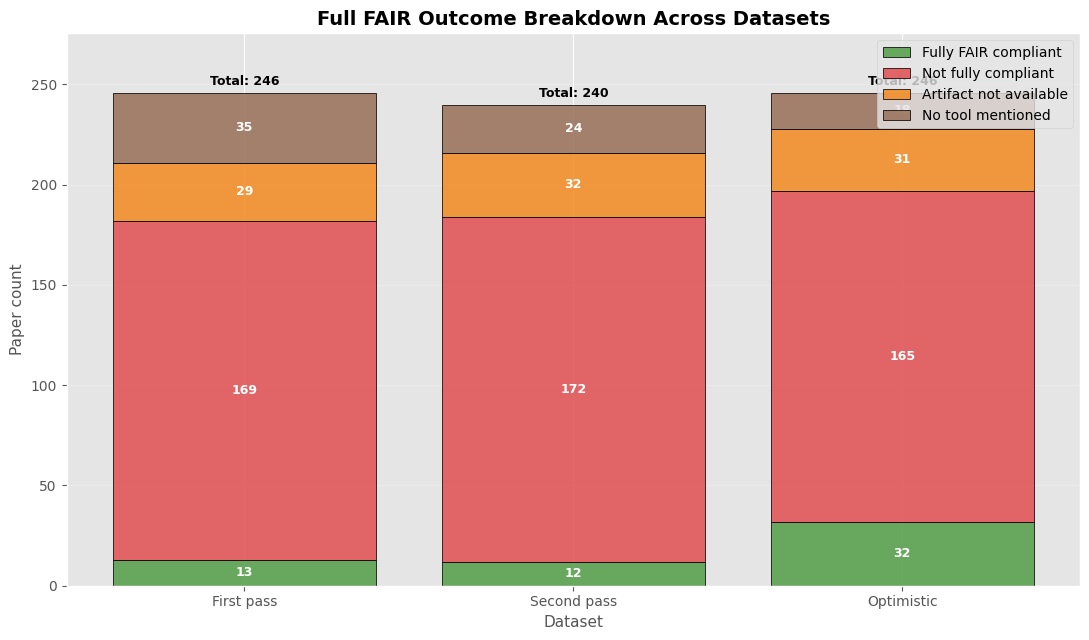

In [ ]:
import importlib
import plotting_scripts.full_fair_compliance as full_fair_compliance

importlib.reload(full_fair_compliance)

# Full FAIR compliance outcome breakdown across first, second, and optimistic datasets
full_fair_compliance.plot_full_fair_compliance(df_first_all, df_second_all, df_optimistic_all)

Saved PNG plot to graphs\distribution_of_fair_criteria_met_per_paper_bar_color_doi_proportion_in_group.png


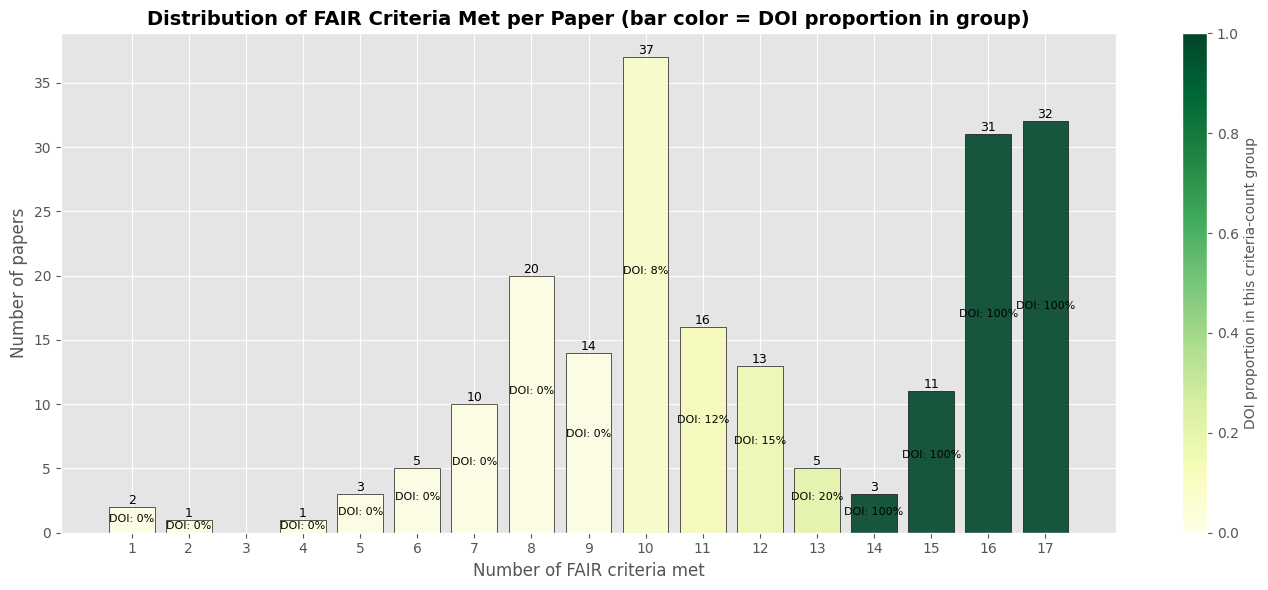

In [ ]:
from plotting_scripts.fair_criteria_distribution import plot_fair_criteria_distribution

# Distribution of number of FAIR criteria met (1..n)
# Bar colors indicate DOI proportion within each criteria-count group.
# Uses selected_dataframe_name from Cell 2.
plot_fair_criteria_distribution(plot_df, F, A, I, R)

Saved PNG plot to graphs\artifact_overlap_between_first_and_second_pass.png


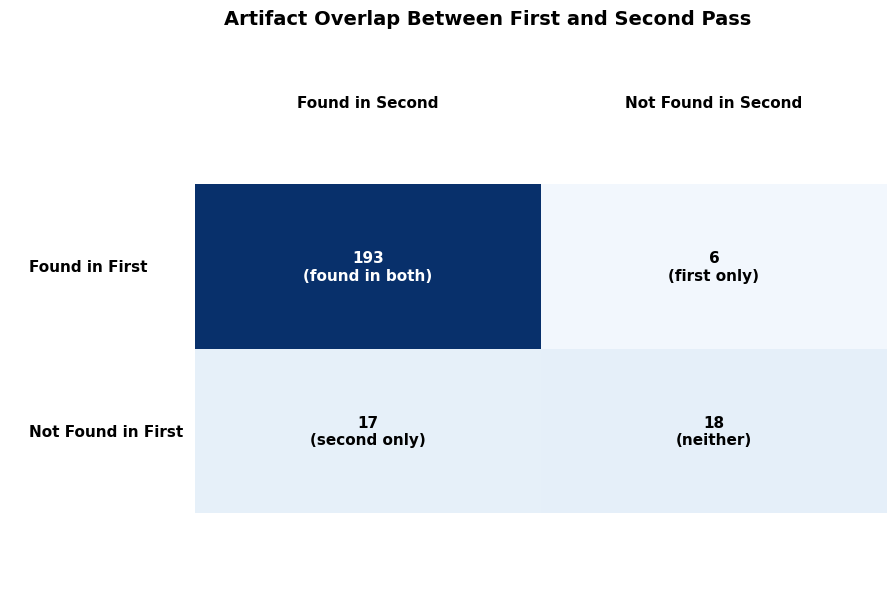

In [ ]:
from plotting_scripts.artifact_overlap import plot_artifact_overlap

# Artifact overlap between first and second pass
plot_artifact_overlap()

Saved PNG plot to graphs\acm_badge_compliance_cascade.png


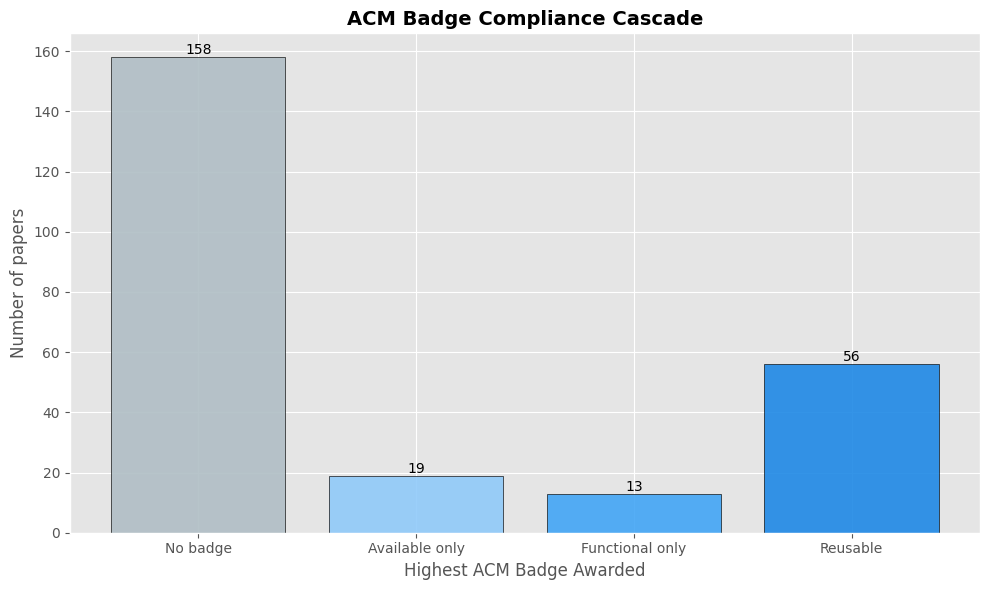

In [ ]:
from plotting_scripts.acm_badge_cascade import plot_acm_badge_cascade

# ACM badge compliance cascade (wider criteria)
plot_acm_badge_cascade(sample_file)

First pass (out of available papers): {'Zenodo Only': 27, 'GitHub Only': 95, 'Figshare Only': 8, 'Zenodo and GitHub': 34, 'Figshare and GitHub': 5, 'Anonymous GitHub Only': 6, 'Google Sites': 2, 'Other': 5}
First pass (out of unavailable papers): {'Zenodo Only': 0, 'GitHub Only': 4, 'Figshare Only': 0, 'Zenodo and GitHub': 0, 'Figshare and GitHub': 0, 'Anonymous GitHub Only': 3, 'Google Sites': 0, 'Not Found': 22}
Second pass (out of available papers): {'Zenodo Only': 20, 'GitHub Only': 108, 'Figshare Only': 8, 'Zenodo and GitHub': 30, 'Figshare and GitHub': 5, 'Anonymous GitHub Only': 7, 'Google Sites': 1, 'Other': 5}
Second pass (out of unavailable papers): {'Zenodo Only': 2, 'GitHub Only': 5, 'Figshare Only': 1, 'Zenodo and GitHub': 0, 'Figshare and GitHub': 0, 'Anonymous GitHub Only': 3, 'Google Sites': 0, 'Not Found': 21}


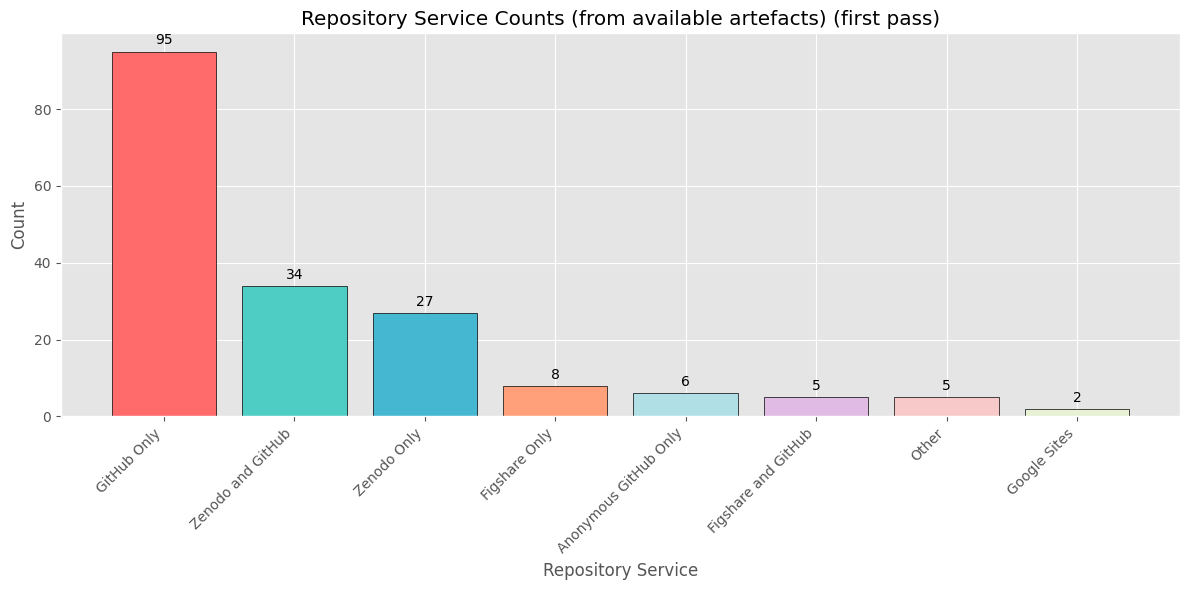

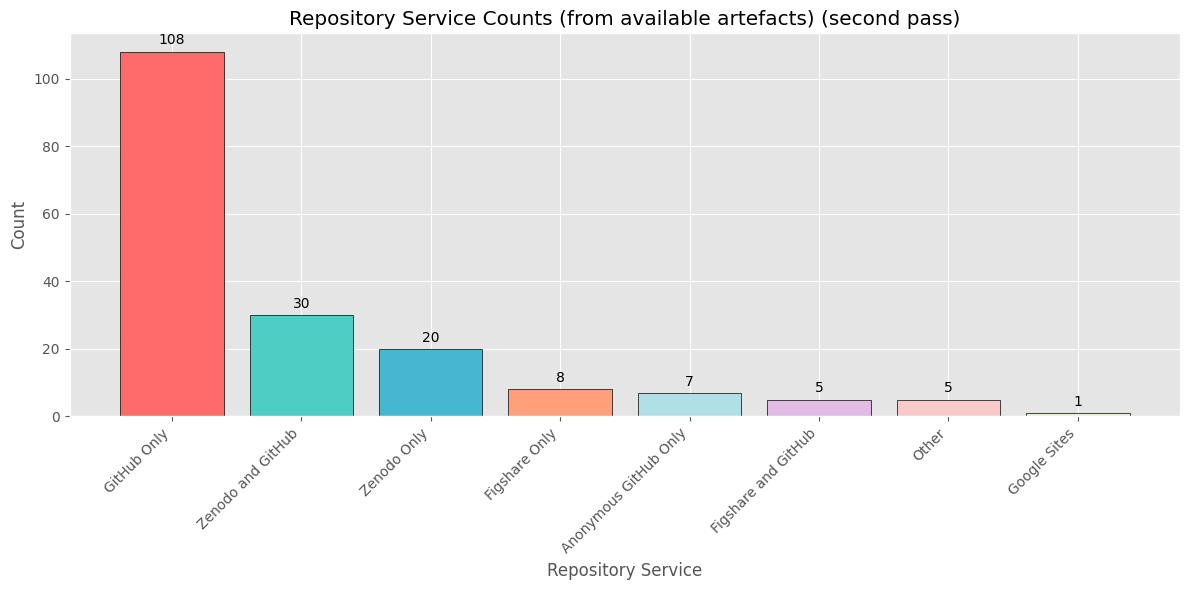

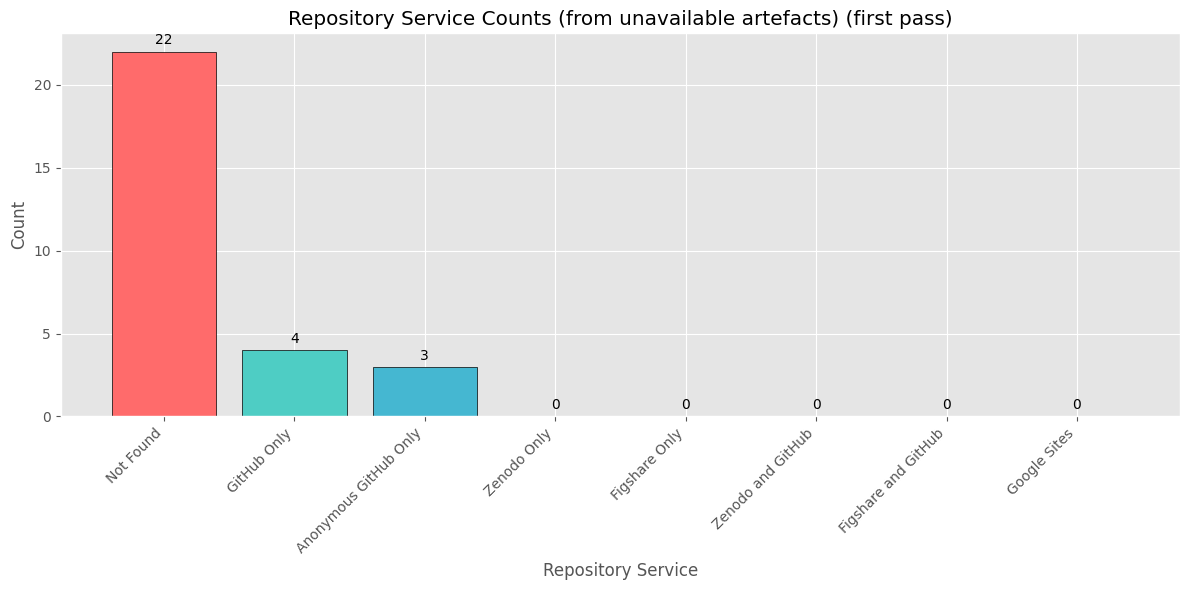

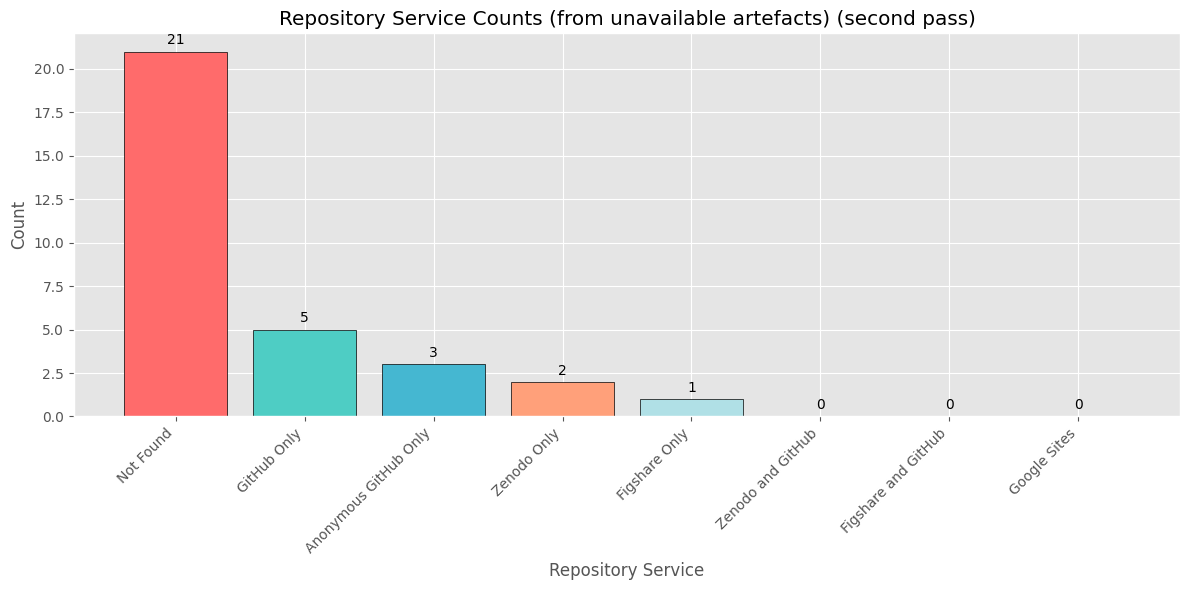

In [ ]:
# Repo stats
repo_stats_main()

In [ ]:
from plotting_scripts.repository_stats import repo_stats_main
from plotting_scripts.artefact_availability import availability_main
availability_main()

First pass: {'Available': 182, 'Unavailable': 29, 'No Artefact': 35}
Second pass: {'Available': 184, 'Unavailable': 32, 'No Artefact': 24}
Error in callback <function flush_figures at 0x000001FB52EF84A0> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 